In [9]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

# ---------------------------------------
# Cypher Queries: universell für jede DB
# ---------------------------------------
COUNT_NODES = """MATCH (n) RETURN count(n) AS nodes;"""
COUNT_EDGES = """MATCH ()-[r]->() RETURN count(r) AS edges;"""

def get_counts(db_name: str) -> dict:
    """Liefert die Anzahl aller Knoten und Kanten für eine Datenbank."""
    with driver.session(database=db_name) as session:
        nodes = session.run(COUNT_NODES).single()["nodes"]
        edges = session.run(COUNT_EDGES).single()["edges"]
    return {"database": db_name, "nodes": nodes, "edges": edges}


# ---------------------------------------
# Deine 4 Datenbanken
# ---------------------------------------
DBS = ["simplekg", "neo4j", "llmakg", "llmagraphtrkg"]

results = [get_counts(db) for db in DBS]

driver.close()

df = pd.DataFrame(results)

# Schönere Namen für die Thesis
rename_map = {
    "simplekg": "KG_Neo4j_Extractor_Version1",
    "neo4j": "KG_Neo4j_Extractor_Version2",
    "llmakg": "KG_LlamaIndex_Extractor",
    "llmagraphtrkg": "KG_Langchain_Extractor",
}
df["database"] = df["database"].replace(rename_map)

print(df)


                      database  nodes  edges
0  KG_Neo4j_Extractor_Version1   1157   1974
1  KG_Neo4j_Extractor_Version2    841   1252
2      KG_LlamaIndex_Extractor   1574   4472
3       KG_Langchain_Extractor    884   2487


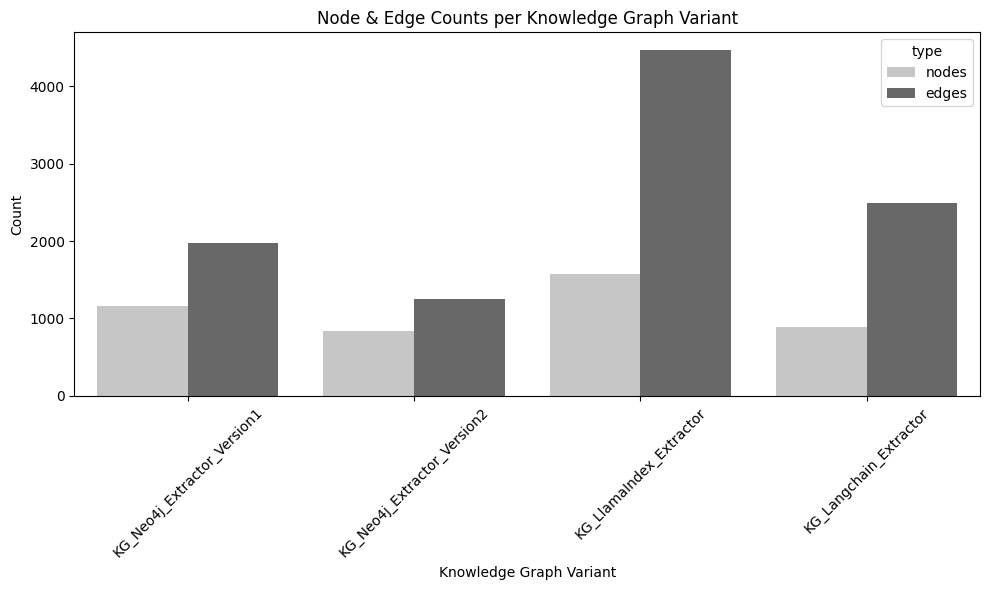

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
df_long = df.melt(
    id_vars="database",
    value_vars=["nodes", "edges"],
    var_name="type",
    value_name="count",
)
# --- Schriftfarbe überall auf Schwarz setzen ---
plt.rcParams['text.color'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_long,
    x="database",
    y="count",
    hue="type",
    palette="Greys"    # Grautöne für die Bars
)

plt.title("Node & Edge Counts per Knowledge Graph Variant")
plt.xlabel("Knowledge Graph Variant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [21]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "testmaster123"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

# ---------------------------------------
# Cypher Queries: universell für jede DB
# ---------------------------------------
COUNT_NODES = """MATCH (n) RETURN count(n) AS nodes;"""
COUNT_EDGES = """MATCH ()-[r]->() RETURN count(r) AS edges;"""

def get_counts(db_name: str) -> dict:
    """Liefert die Anzahl aller Knoten und Kanten für eine Datenbank."""
    with driver.session(database=db_name) as session:
        nodes = session.run(COUNT_NODES).single()["nodes"]
        edges = session.run(COUNT_EDGES).single()["edges"]
    return {"database": db_name, "nodes": nodes, "edges": edges}


# ---------------------------------------
# Deine 4 Datenbanken
# ---------------------------------------
DBS = ["eval-llmgraph", "eval-llmaindex" ,"eval-simlekg",]

results = [get_counts(db) for db in DBS]

driver.close()

df = pd.DataFrame(results)

# Schönere Namen für die Thesis
rename_map = {
    "eval-simlekg": "KG_Neo4j_Extractor_Version1",
    "eval-llmaindex": "KG_LlamaIndex_Extractor",
    "eval-llmgraph": "KG_Langchain_Extractor",
}
df["database"] = df["database"].replace(rename_map)

print(df)


Unable to retrieve routing information


ServiceUnavailable: Unable to retrieve routing information

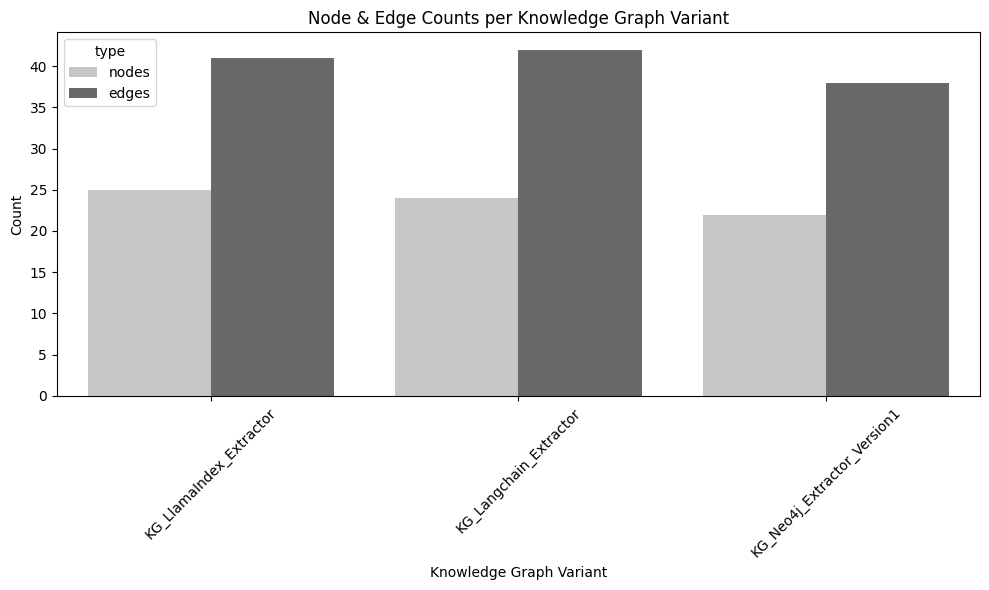

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
df_long = df.melt(
    id_vars="database",
    value_vars=["nodes", "edges"],
    var_name="type",
    value_name="count",
)
# --- Schriftfarbe überall auf Schwarz setzen ---
plt.rcParams['text.color'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_long,
    x="database",
    y="count",
    hue="type",
    palette="Greys"    # Grautöne für die Bars
)

plt.title("Node & Edge Counts per Knowledge Graph Variant")
plt.xlabel("Knowledge Graph Variant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

def run_query_to_df(query: str, database: str) -> pd.DataFrame:
    """Generic function to run a Cypher query on a given database and return a DataFrame."""
    with driver.session(database=database) as session:
        result = session.run(query)
        records = list(result)
        
        if not records:
            return pd.DataFrame()  # empty
        
        # Neo4j returns dict-like records → convert to list of dicts
        rows = [r.data() for r in records]
        return pd.DataFrame(rows)

In [8]:
DATABASE_llmgraph="eval-llmgraph"
DATABASE_llmaindex="eval-llmaindex"
DATABASE_simple_kg = "eval-simlekg"

In [ ]:
query_llmagraph = """MATCH (s)-[r]-(o)

// Chunk-ID für Subjekt (bidirektional)
OPTIONAL MATCH (s)-[:MENTIONS]-(cs1:Chunk)
OPTIONAL MATCH (cs2:Chunk)-[:MENTIONS]-(s)

// Chunk-ID für Objekt
OPTIONAL MATCH (o)-[:MENTIONS]-(co1:Chunk)
OPTIONAL MATCH (co2:Chunk)-[:MENTIONS]-(o)

// 👉 FILTER NACHDEM chunk_ids gesammelt wurden
WHERE NOT type(r) CONTAINS "MENTIONS"
  AND NOT toLower(type(r)) CONTAINS "document"

RETURN
  coalesce(s.id, s.name, s.entityType, "UNKNOWN") AS subject,
  type(r)                                         AS relation,
  coalesce(o.id, o.name, o.entityType, "UNKNOWN") AS object,

  coalesce(cs1.chunk_id, cs2.chunk_id, "NO_CHUNK") AS subject_chunk,
  coalesce(co1.chunk_id, co2.chunk_id, "NO_CHUNK") AS object_chunk;
;
"""
query_simplekg ="""MATCH (s)-[r]-(o)
WHERE NOT type(r) CONTAINS ("CHUNK")
AND NOT toLower(type(r)) CONTAINS "document"
RETURN
  coalesce(s.type, s.name, "UNKNOWN") AS s_value,
  type(r)                             AS relation,
  coalesce(o.type, o.name, "UNKNOWN") AS o_value;"""
query_llmaindex = """MATCH (s)-[r]-(o)


WHERE NOT type(r) CONTAINS "MENTIONS"
  AND NOT toLower(type(r)) CONTAINS "document"

RETURN
  coalesce(s.id, s.name, s.entityType, "UNKNOWN") AS subject,
  type(r)                                         AS relation,
  coalesce(o.id, o.name, o.entityType, "UNKNOWN") AS object,

  coalesce(s.chunk_id, "NO_CHUNK") AS subject_chunk,
  coalesce(o.chunk_id, "NO_CHUNK") AS object_chunk;
;"""

In [10]:
df_llmagraph = run_query_to_df(query_llmagraph, DATABASE_llmgraph)
df_llmaindex = run_query_to_df(query_llmaindex, DATABASE_llmaindex)
df_simplekg = run_query_to_df(query_simplekg, DATABASE_simple_kg)

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: type)} {position: line: 5, column: 14, offset: 120} for query: 'MATCH (s)-[r]-(o)\nWHERE NOT type(r) CONTAINS ("MENTIONS")\nAND NOT toLower(type(r)) CONTAINS "document"\nRETURN\n  coalesce(s.type, s.name, "UNKNOWN") AS s_value,\n  type(r)                             AS relation,\n  coalesce(o.type, o.name, "UNKNOWN") AS o_value;'
Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One

In [17]:
df_llmagraph

,s_value,relation,o_value,source
0,Arduino Due,USES,Atmel Sam3X8E,llmagraph
1,Atmel Sam3X8E,USES,Arduino Due,llmagraph
2,Arduino Due,SUPPORTS,Embedded Systems Development,llmagraph
3,Embedded Systems Development,SUPPORTS,Arduino Due,llmagraph
4,Arduino Due,SUPPORTS,Robotics,llmagraph
5,Robotics,SUPPORTS,Arduino Due,llmagraph
6,Arduino Due,SUPPORTS,3D Printing & Cnc Machines,llmagraph
7,3D Printing & Cnc Machines,SUPPORTS,Arduino Due,llmagraph
8,Arduino Due,SUPPORTS,Prototyping,llmagraph
9,Prototyping,SUPPORTS,Arduino Due,llmagraph


In [18]:
df_llmaindex

,s_value,relation,o_value,source
0,Arduino due,Has,32-bit architecture,llmaindex
1,32-bit architecture,Has,Arduino due,llmaindex
2,Arduino due,Has,Clock speed of 84 mhz,llmaindex
3,Clock speed of 84 mhz,Has,Arduino due,llmaindex
4,Arduino due,Combines,Atmel sam3x8e microcontroller,llmaindex
5,Atmel sam3x8e microcontroller,Combines,Arduino due,llmaindex
6,Arduino due,Offers,Versatile solution,llmaindex
7,Versatile solution,Offers,Arduino due,llmaindex
8,Arduino due,Can serve as,Brain of autonomous mobile robot,llmaindex
9,Brain of autonomous mobile robot,Can serve as,Arduino due,llmaindex


In [19]:
df_simplekg

,s_value,relation,o_value,source
0,Arduino Due,FROM_CHUNK,UNKNOWN,simplekg
1,UNKNOWN,FROM_CHUNK,Arduino Due,simplekg
2,Arduino Due,UTILIZES,temperature,simplekg
3,temperature,UTILIZES,Arduino Due,simplekg
4,Arduino Due,UTILIZES,humidity,simplekg
...,...,...,...,...
67,UNKNOWN,FROM_CHUNK,temperature sensor,simplekg
68,humidity sensor,FROM_CHUNK,UNKNOWN,simplekg
69,UNKNOWN,FROM_CHUNK,humidity sensor,simplekg
70,tropical,FROM_CHUNK,UNKNOWN,simplekg


In [20]:
df_llmagraph["source"] = "llmagraph"
df_llmaindex["source"] = "llmaindex"
df_simplekg["source"] = "simplekg"

df_all = pd.concat([df_llmagraph, df_llmaindex, df_simplekg], ignore_index=True)
df_all


,s_value,relation,o_value,source
0,Arduino Due,USES,Atmel Sam3X8E,llmagraph
1,Atmel Sam3X8E,USES,Arduino Due,llmagraph
2,Arduino Due,SUPPORTS,Embedded Systems Development,llmagraph
3,Embedded Systems Development,SUPPORTS,Arduino Due,llmagraph
4,Arduino Due,SUPPORTS,Robotics,llmagraph
...,...,...,...,...
143,UNKNOWN,FROM_CHUNK,temperature sensor,simplekg
144,humidity sensor,FROM_CHUNK,UNKNOWN,simplekg
145,UNKNOWN,FROM_CHUNK,humidity sensor,simplekg
146,tropical,FROM_CHUNK,UNKNOWN,simplekg


In [22]:
from pathlib import Path

RESULT_PATH = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\triples\triples_result_chunks.csv")

df_all.to_csv(RESULT_PATH, index=False)